# Demo for Bi-fidelity Stochastic Subspace Descent

We consider training a neural network using gradient-free methods. For convenience we train a basic CNN.


In [36]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import random
from torch.utils.data import Subset
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import copy

from wrapper import *

In [37]:
batch_size = 10

# Define the CNN model
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 1, 3, 1)   # Reduced number of filters
        self.conv2 = nn.Conv2d(1, 1, 3, 1)   # Reduced number of filters
        self.fc1 = nn.Linear(25, 10)        # Smaller fully connected layer
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = torch.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = self.conv2(x)
        x = torch.relu(x)
        x = torch.max_pool2d(x, 2)
        x = self.dropout2(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)

        return torch.log_softmax(x, dim=1)

# Define transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./MNIST', train=True, download=False, transform=transform)
test_dataset = datasets.MNIST(root='./MNIST', train=False, download=False, transform=transform)

# Filter function to only keep labels 0 to 7
def filter_mnist(dataset, allowed_labels):
    mask = torch.tensor([label in allowed_labels for label in dataset.targets])
    new_dataset = copy.copy(dataset)
    new_dataset.data = dataset.data[mask]
    new_dataset.targets = dataset.targets[mask]
    return new_dataset

# Define allowed labels (0 to 7)
pretrain_labels = list(range(8))

# Apply filtering to the train and test datasets
pretrain_train_dataset = filter_mnist(train_dataset, pretrain_labels)
pretrain_test_dataset = filter_mnist(test_dataset, pretrain_labels)

# Create DataLoaders
train_loader = DataLoader(pretrain_train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(pretrain_test_dataset, batch_size=64, shuffle=False)

# Initialize the model, optimizer, and loss function
model = CNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.NLLLoss()

# Training the model
def train(model, device, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}]\tLoss: {loss.item():.6f}')

# Testing the model
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)} ({100. * correct / len(test_loader.dataset):.0f}%)\n')

In [27]:
# Set up the device for GPU or CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # Run training and testing loop
# n_epochs = 5
# for epoch in range(1, n_epochs + 1):
#     train(model, device, train_loader, optimizer, epoch)
#     test(model, device, test_loader)

# Calculate the total number of parameters in the model
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

# # Save the model
# torch.save(model.state_dict(), "MNIST/mnist_cnn.pt")

Train Epoch: 1 [0/48200]	Loss: 2.289269
Train Epoch: 1 [6400/48200]	Loss: 1.887182
Train Epoch: 1 [12800/48200]	Loss: 1.503035
Train Epoch: 1 [19200/48200]	Loss: 1.334600
Train Epoch: 1 [25600/48200]	Loss: 1.338256
Train Epoch: 1 [32000/48200]	Loss: 1.541936
Train Epoch: 1 [38400/48200]	Loss: 1.339350
Train Epoch: 1 [44800/48200]	Loss: 1.166020

Test set: Average loss: 0.0143, Accuracy: 6756/8017 (84%)

Train Epoch: 2 [0/48200]	Loss: 1.460439
Train Epoch: 2 [6400/48200]	Loss: 1.095951
Train Epoch: 2 [12800/48200]	Loss: 1.026518
Train Epoch: 2 [19200/48200]	Loss: 1.283501
Train Epoch: 2 [25600/48200]	Loss: 1.332231
Train Epoch: 2 [32000/48200]	Loss: 1.114892
Train Epoch: 2 [38400/48200]	Loss: 1.074357
Train Epoch: 2 [44800/48200]	Loss: 1.071725

Test set: Average loss: 0.0129, Accuracy: 6774/8017 (84%)

Train Epoch: 3 [0/48200]	Loss: 1.140869
Train Epoch: 3 [6400/48200]	Loss: 1.265608
Train Epoch: 3 [12800/48200]	Loss: 1.261940
Train Epoch: 3 [19200/48200]	Loss: 1.074816
Train Epoch: 3 

In [42]:
# Load the model
model = CNN()
model.load_state_dict(torch.load("MNIST/mnist_cnn.pt", weights_only=False))
model.to(device)

# Test model on non-trained labels
nontrain_labels = list(range(8, 10))
nontrain_train_dataset = filter_mnist(train_dataset, nontrain_labels)
nontrain_test_dataset = filter_mnist(test_dataset, nontrain_labels)
nontrain_test_loader = DataLoader(nontrain_test_dataset, batch_size=64, shuffle=False)

# Test the model on non-trained labels
test(model, device, nontrain_test_loader)


Test set: Average loss: 0.2361, Accuracy: 0/1983 (0%)



In [45]:
# Assume test_dataset is already loaded as described in previous code
def generate_subset_test(test_dataset, percentage=1e-3):
    # Get the total number of samples in the test dataset
    total_samples = len(test_dataset)
    print(f"Total number of samples in the train dataset: {total_samples}")

    # Calculate the number of samples corresponding to 1%
    num_samples_1_percent = int(percentage * total_samples)

    # Randomly select 1% of the indices from the test dataset
    random_indices = random.sample(range(total_samples), num_samples_1_percent)

    # Create a subset of the test dataset using these random indices
    test_subset = Subset(test_dataset, random_indices)

    # Create a new DataLoader for the subsampled data
    subsampled_test_loader = DataLoader(test_subset, batch_size=1000, shuffle=False)

    return subsampled_test_loader

# Load model
def load_model():
    model = CNN()
    model.load_state_dict(torch.load("MNIST/mnist_cnn.pt", weights_only=False))
    model.to(device)
    return model


In [46]:
# nontrain_train_loader = DataLoader(nontrain_train_dataset, batch_size=batch_size, shuffle=False)
subsampled_train_loader = generate_subset_test(nontrain_train_dataset, percentage=1e-2)

print(f"Subsample train loader size {len(subsampled_train_loader)}")

Total number of samples in the train dataset: 11800
Subsample train loader size 1


In [48]:
def evaluate(model, test_loader, device):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += criterion(output, target).item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    return test_loss

def f_HF(x):
    # Convert the NumPy array to a PyTorch tensor
    new_params = torch.from_numpy(x).float()  # Ensure the type matches

    # After modifying the flattened tensor, update the original parameters
    start = 0
    for param in model.parameters():
        num_params = param.numel()
        param.data = new_params[start:start + num_params].view(param.size())
        start += num_params

    # Evaluate after modification
    test_loss = evaluate(model, test_loader, device)

    return test_loss

def f_LF(x):
    # Convert the NumPy array to a PyTorch tensor
    new_params = torch.from_numpy(x).float()  # Ensure the type matches

    # After modifying the flattened tensor, update the original parameters
    start = 0
    for param in model.parameters():
        num_params = param.numel()
        param.data = new_params[start:start + num_params].view(param.size())
        start += num_params

    # Evaluate after modification
    test_loss = evaluate(model, subsampled_train_loader, device)

    return test_loss

x = np.random.rand(total_params)
LF_loss = f_LF(x)
HF_loss = f_HF(x)

print(f"High-fidelity loss: {HF_loss:.4f}")
print(f"Low-fidelity loss: {LF_loss:.4f}")


High-fidelity loss: 1.0110
Low-fidelity loss: 0.2347


In [76]:
obj = objectiveFcn(f_HF,label='HF')
obj_lowFi= objectiveFcn(f_LF,label='LF')
obj_alt = objectiveFcn(f_HF,label='HF-alt')

# initial point
d = total_params
x0 = 1e-1 * np.random.randn(d)
learning_rate = 1e-2
ell = 20
num_iterations = 10
learning_rate_ssd = learning_rate*ell/d
linesearchIter = 10
c = 0.9

In [77]:

num_trials = 1
methods = ['gd', 'cd', 'ssd', 'spsa', 'rgfm', 'ssd_lf', 'ssd_hf', 'ssd_bf', 'ssd_oracle']
methods = ['gd', 'cd', 'ssd', 'spsa', 'ssd_bf']
res = {m: [] for m in methods}
# gd, cd, ssdd, spsa_ls, rgfm, ssdd_ls, ssdh_ls, ssdd_bt, ssdd_hbt = [], [], [], [], [], [], [], [], []
for i in tqdm(range(num_trials)):
    # Gradient Descent
    if 'gd' in methods:
        model = load_model()
        _ = grad_desc(x0,obj,learning_rate=learning_rate,num_iterations=num_iterations)
        res['gd'].append(obj.returnHistory())
     # Coordinate Descent
    if 'cd' in methods:
        model = load_model()
        _ = coor_desc(x0,obj,learning_rate=learning_rate,num_iterations=num_iterations/2)
        res['cd'].append(obj.returnHistory())
    # SSD
    if 'ssd' in methods:
        model = load_model()
        _ = ssd(x0,obj,ell=ell,learning_rate=learning_rate_ssd,num_iterations=num_iterations*d/ell)
        res['ssd'].append(obj.returnHistory())
    # SPSA
    if 'spsa' in methods:
        model = load_model()
        _ = spsa(x0,obj,num_iterations=num_iterations*d)
        res['spsa'].append(obj.returnHistory())
    # Random Gredien-free Minimization
    if 'rgfm' in methods:
        model = load_model()
        _ = ssd(x0,obj,ell=1,learning_rate=learning_rate_ssd,num_iterations=num_iterations*d)
        res['rgfm'].append(obj.returnHistory())
    # SSD with linesearch (LF)
    if 'ssd_lf' in methods:
        model = load_model()
        _ = ssd_ls(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_lowFi,
                    num_iterations=num_iterations*d/ell, linesearchIter=linesearchIter )
        res['ssd_lf'].append(obj.returnHistory())
    # model = load_model()
    # _ = ssd_ls(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_lowFi,
    #             num_iterations=num_iterations*d/ell, linesearchIter=linesearchIter )
    # res['ssd_lf'].append(obj.returnHistory())
    # SSD with linesearch (HF)
    if 'ssd_oracle' in methods:
        model = load_model()
        _ = ssd_ls(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_alt,
                    num_iterations=num_iterations*d/ell, linesearchIter=linesearchIter )
        res['ssd_oracle'].append(obj.returnHistory())
    # model = load_model()
    # _ = ssd_ls(x0,obj,ell=ell,learning_rate=learning_rate_ssd, obj_lowFi= obj_alt,
    #             num_iterations=num_iterations*d/ell, linesearchIter=linesearchIter )
    # res['ssd_oracle'].append(obj.returnHistory())
    # SSD with backtracking linesearch (BF)
    if 'ssd_bf' in methods:
        model = load_model()
        _ = ssd_bt(x0,obj,ell=ell,obj_lowFi= obj_lowFi, c=c,
                    num_iterations=num_iterations*d/ell, linesearchIter=linesearchIter )
        res['ssd_bf'].append(obj.returnHistory())
    # SSD with backtracking linesearch (HF)
    if 'ssd_hf' in methods:
        model = load_model()
        _ = ssd_hbt(x0,obj,ell=ell,obj_lowFi= obj_lowFi, c=c,
                    num_iterations=num_iterations*d/ell, linesearchIter=linesearchIter )
        res['ssd_hf'].append(obj.returnHistory())


  0%|          | 0/1 [00:00<?, ?it/s]

======== gradient descent ======
======== coordinate descent ========
======== SSD ===================
======== SPSA ===================
======== SSD w/ backtracking bi-fi linesearch =


100%|██████████| 1/1 [1:17:08<00:00, 4628.92s/it]


In [78]:
# Collect data and compute mean/std
T = num_iterations * d
res_mean, res_std = {}, {}
for k, v in res.items():
    res[k] = np.array(v)
    res_mean[k], res_std[k] = np.mean(res[k][:,10:T], axis=0), np.std(res[k][:,10:T], axis=0)

 <>:24: SyntaxWarning:invalid escape sequence '\e'
 <>:24: SyntaxWarning:invalid escape sequence '\e'
 /var/folders/2h/qpgmp2hn60v7bxdrwgqzjb9r0000gn/T/ipykernel_18230/2091503063.py:24: SyntaxWarning:invalid escape sequence '\e'


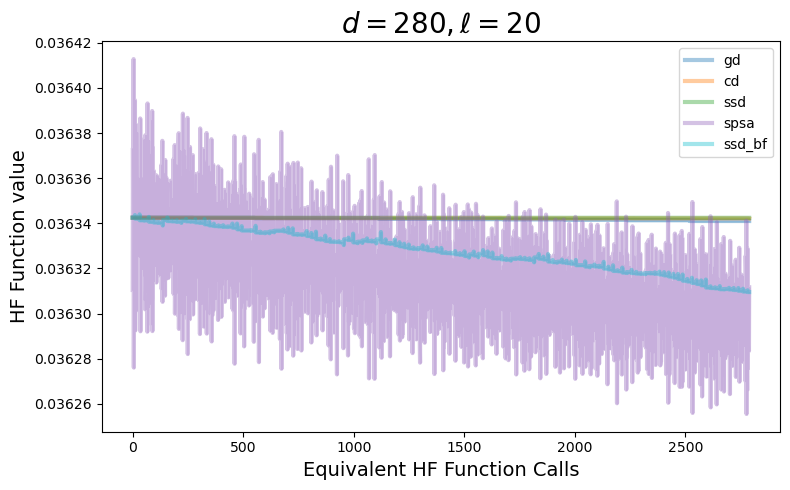

In [80]:
t = np.arange(0, T - 10)
bf_ratio = 1.0#linesearchIter * r2 / ((ell + 1) * r1)
bf_t = (1 + bf_ratio) * t
lw = 3.0
colors = {
    'gd': 'tab:blue',
    'cd': 'tab:orange',
    'ssd': 'tab:green',
    'spsa': 'tab:purple',
#    'rgfm': 'tab:brown',
#    'ssd_lf': 'tab:red',
#    'ssd_hf': 'tab:olive',
    'ssd_bf': 'tab:cyan',
#    'ssd_oracle': 'tab:pink'
}

plt.figure(figsize=(8,5))
for k in colors:
    plt.plot(t[:len(res_mean[k])], res_mean[k], label=k, color=colors[k], lw=lw, alpha=0.4)
    plt.fill_between(t[:len(res_mean[k])], res_mean[k]-1.94*res_std[k], res_mean[k]+1.94*res_std[k], alpha=0.2, color=colors[k])
#plt.yscale('log')
#plt.xlim(0, 500)
plt.xlabel('Equivalent HF Function Calls', fontsize=14), plt.ylabel('HF Function value', fontsize=14), plt.legend()
plt.title(f'$d = {d:.0f}, \ell = {ell:.0f}$', fontsize=20)
plt.tight_layout()
# plt.savefig(f'figures-worst/d{d:.0f}-ell{ell:.0f}-rH{r1:.0f}-rL{r2:.0f}.pdf', dpi=200, bbox_inches='tight')